In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

In [2]:
data_dir = Path("./req_100_batch_4")

Found 9 data points to plot.


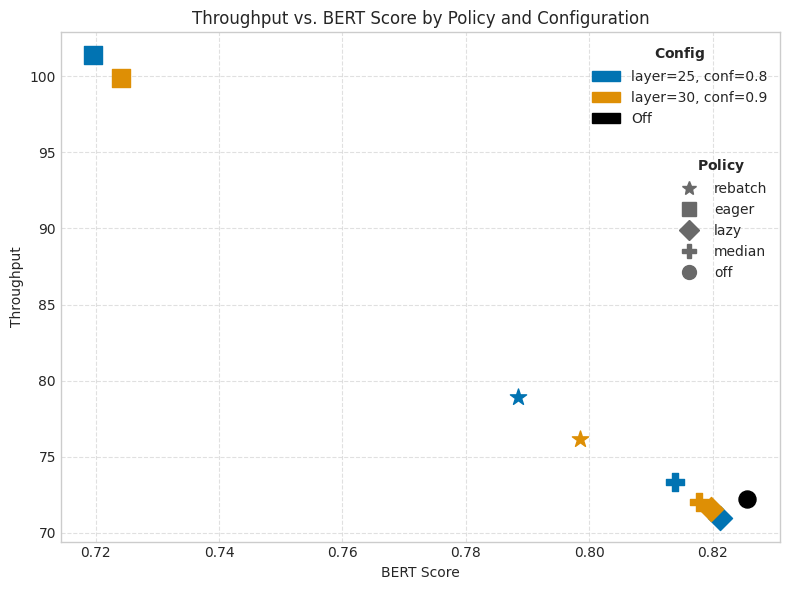

       policy layer conf  throughput  bert_score  + thro (%)  - bert (%)  \
0         off    50  0.7   72.195163    0.825638    0.000000    0.000000   
1  rebatching    50  0.7   78.917561    0.788414    0.093114    0.045084   
2      median    50  0.7   73.313402    0.813976    0.015489    0.014124   
3       eager    50  0.7  101.367077    0.719645    0.404070    0.128377   
4        lazy    50  0.7   70.939380    0.821211   -0.017394    0.005361   
5  rebatching    50  0.9   76.141871    0.798451    0.054667    0.032929   
6      median    50  0.9   72.046054    0.817864   -0.002065    0.009416   
7        lazy    50  0.9   71.542930    0.819711   -0.009034    0.007178   
8       eager    50  0.9   99.886341    0.724054    0.383560    0.123036   

   ee_efficacy  
0          NaN  
1     2.065331  
2     1.096661  
3     3.147532  
4    -3.244350  
5     1.660177  
6    -0.219356  
7    -1.258666  
8     3.117452  


In [31]:
def plot_throughput_vs_bert_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure.
    """
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "off": {"label": "off", "marker": "o"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue

            df = pd.read_csv(csv_path)
            throughput = df["throughput"].mean()
            bert_score = df["bert_score"].mean()
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "bert_score": bert_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the 'off' policy data point
    subdf_off = plot_df[plot_df["policy"] == "off"]
    if not subdf_off.empty:
        ax.scatter(
            subdf_off["bert_score"], subdf_off["throughput"],
            marker=policies["off"]["marker"], color="black", s=150, zorder=3
        )

    # Plot data points for other policies and configs
    for policy, p_info in policies.items():
        if policy == "off":
            continue
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                ax.scatter(
                    subdf["bert_score"], subdf["throughput"],
                    marker=p_info["marker"], color=color, s=150, zorder=3
                )

    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=25, conf=0.8"),
        mpatches.Patch(color=palette[1], label="layer=30, conf=0.9"),
        mpatches.Patch(color='black', label="Off")
    ]
    # Create the first legend and specify its location
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                              loc='upper right', bbox_to_anchor=(1, 1))

    # **Add the first legend to the axes manually**
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers)
    policy_order = ["rebatching", "eager", "lazy", "median", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    # Create the second legend, placing it below the first one by adjusting
    # the vertical component of `bbox_to_anchor`.
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='upper right', bbox_to_anchor=(1, 0.78))

    # --- Final Touches ---
    ax.set_xlabel("BERT Score")
    ax.set_ylabel("Throughput")
    ax.set_title("Throughput vs. BERT Score by Policy and Configuration")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    off_throughput = plot_df[plot_df["policy"] == "off"]["throughput"].mean()
    off_bert_score = plot_df[plot_df["policy"] == "off"]["bert_score"].mean()
    improvement_in_throughput = (plot_df["throughput"] - off_throughput) / off_throughput
    decrease_in_bert = (off_bert_score - plot_df["bert_score"]) / off_bert_score
    ee_efficacy = improvement_in_throughput / decrease_in_bert
    plot_df["+ thro (%)"] = improvement_in_throughput
    plot_df["- bert (%)"] = decrease_in_bert
    plot_df["ee_efficacy"] = ee_efficacy
    print(plot_df)

plot_throughput_vs_bert_from_csvs(data_dir)

Found 9 data points to plot.


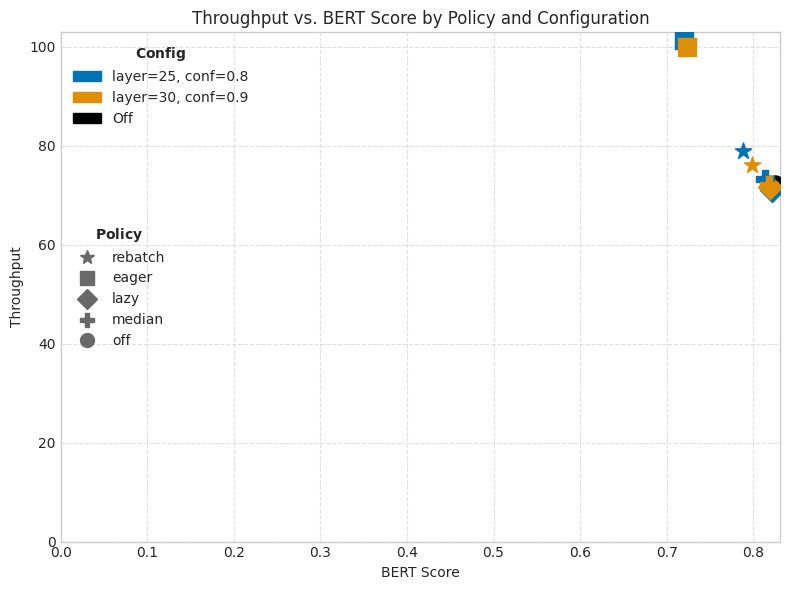

In [29]:
def plot_throughput_vs_bert_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure.
    """
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "off": {"label": "off", "marker": "o"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue

            df = pd.read_csv(csv_path)
            throughput = df["throughput"].mean()
            bert_score = df["bert_score"].mean()
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "bert_score": bert_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the 'off' policy data point
    subdf_off = plot_df[plot_df["policy"] == "off"]
    if not subdf_off.empty:
        ax.scatter(
            subdf_off["bert_score"], subdf_off["throughput"],
            marker=policies["off"]["marker"], color="black", s=150, zorder=3
        )

    # Plot data points for other policies and configs
    for policy, p_info in policies.items():
        if policy == "off":
            continue
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                ax.scatter(
                    subdf["bert_score"], subdf["throughput"],
                    marker=p_info["marker"], color=color, s=150, zorder=3
                )

    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=25, conf=0.8"),
        mpatches.Patch(color=palette[1], label="layer=30, conf=0.9"),
        mpatches.Patch(color='black', label="Off")
    ]
    # Create the first legend and specify its location
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                              loc='upper left')

    # **Add the first legend to the axes manually**
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers)
    policy_order = ["rebatching", "eager", "lazy", "median", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    # Create the second legend, placing it below the first one by adjusting
    # the vertical component of `bbox_to_anchor`.
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='center left',)
    
    # Make y start at 0
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=0)

    # --- Final Touches ---
    ax.set_xlabel("BERT Score")
    ax.set_ylabel("Throughput")
    ax.set_title("Throughput vs. BERT Score by Policy and Configuration")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
plot_throughput_vs_bert_from_csvs(data_dir)

Found 9 data points to plot.


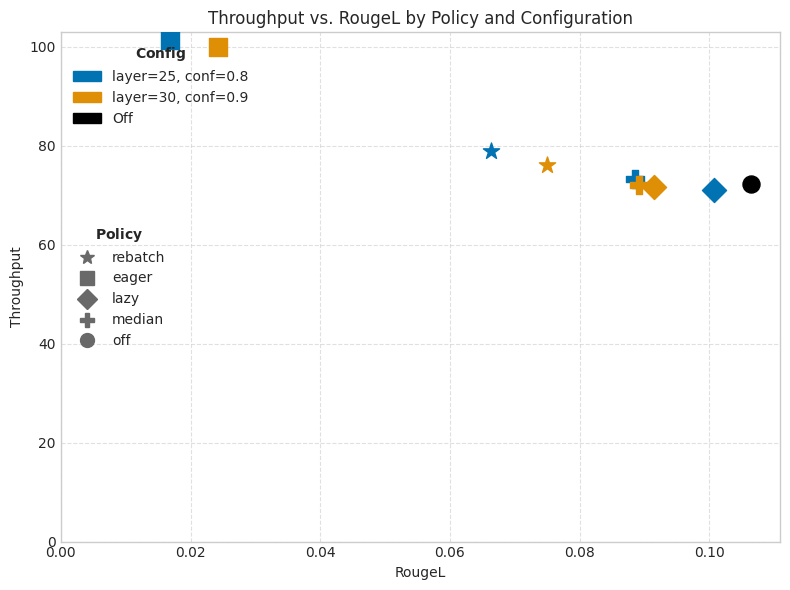

In [34]:
def plot_throughput_vs_rougeL_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure.
    """
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "off": {"label": "off", "marker": "o"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue

            df = pd.read_csv(csv_path)
            throughput = df["throughput"].mean()
            rougeL = df["rougeL"].mean()
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "rougeL": rougeL,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the 'off' policy data point
    subdf_off = plot_df[plot_df["policy"] == "off"]
    if not subdf_off.empty:
        ax.scatter(
            subdf_off["rougeL"], subdf_off["throughput"],
            marker=policies["off"]["marker"], color="black", s=150, zorder=3
        )

    # Plot data points for other policies and configs
    for policy, p_info in policies.items():
        if policy == "off":
            continue
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                ax.scatter(
                    subdf["rougeL"], subdf["throughput"],
                    marker=p_info["marker"], color=color, s=150, zorder=3
                )

    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=25, conf=0.8"),
        mpatches.Patch(color=palette[1], label="layer=30, conf=0.9"),
        mpatches.Patch(color='black', label="Off")
    ]
    # Create the first legend and specify its location
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                              loc='upper left')

    # **Add the first legend to the axes manually**
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers)
    policy_order = ["rebatching", "eager", "lazy", "median", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    # Create the second legend, placing it below the first one by adjusting
    # the vertical component of `bbox_to_anchor`.
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='center left',)
    
    # Make y start at 0
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=0)

    # --- Final Touches ---
    ax.set_xlabel("RougeL")
    ax.set_ylabel("Throughput")
    ax.set_title("Throughput vs. RougeL by Policy and Configuration")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
plot_throughput_vs_rougeL_from_csvs(data_dir)

Found 9 data points to plot.


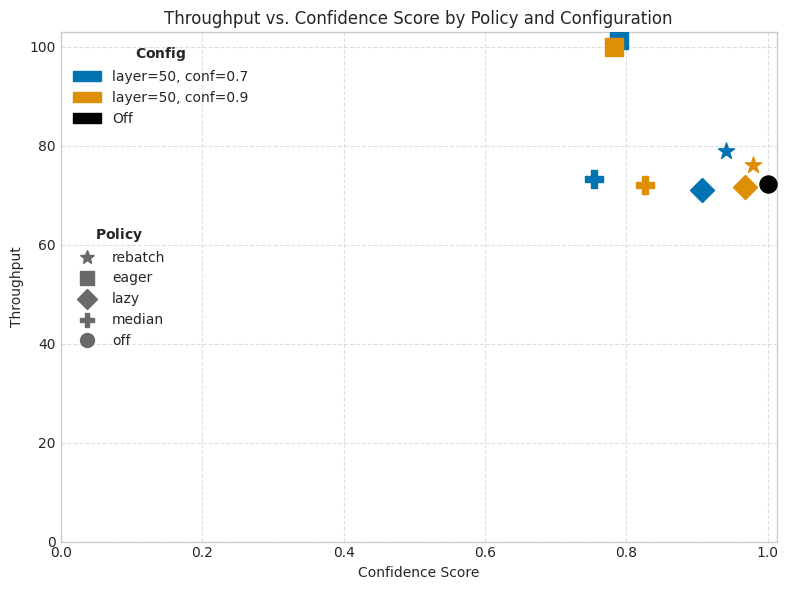

In [38]:
def plot_throughput_vs_conf_score_from_csvs(data_dir):
    """
    Plots throughput vs. BERT score, creating two separate legends for
    policies (markers) and configurations (colors) stacked together in the
    upper-right corner of the figure.
    """
    # Define policies, configs, and their visual properties
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "off": {"label": "off", "marker": "o"},
    }
    # Define the specific configs and their associated colors
    palette = sns.color_palette("colorblind", n_colors=2)
    config_color_map = {
        ("50", "0.7"): palette[0],
        ("50", "0.9"): palette[1],
    }

    # --- Data Preparation ---
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
        if m:
            layer, conf, policy = m.group(1), m.group(2), m.group(3)

            if policy not in policies:
                continue
            if policy != 'off' and (layer, conf) not in config_color_map:
                continue

            df = pd.read_csv(csv_path)
            throughput = df["throughput"].mean()
            confidence_score = df["avg_conf_score_ee"].mean()
            if policy == "off":
                confidence_score = 1
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "throughput": throughput,
                "confidence_score": confidence_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points to plot.")

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot the 'off' policy data point
    subdf_off = plot_df[plot_df["policy"] == "off"]
    if not subdf_off.empty:
        ax.scatter(
            subdf_off["confidence_score"], subdf_off["throughput"],
            marker=policies["off"]["marker"], color="black", s=150, zorder=3
        )

    # Plot data points for other policies and configs
    for policy, p_info in policies.items():
        if policy == "off":
            continue
        for (layer, conf), color in config_color_map.items():
            subdf = plot_df[
                (plot_df["policy"] == policy) &
                (plot_df["layer"] == layer) &
                (plot_df["conf"] == conf)
            ]
            if not subdf.empty:
                ax.scatter(
                    subdf["confidence_score"], subdf["throughput"],
                    marker=p_info["marker"], color=color, s=150, zorder=3
                )

    # --- Manual Legend Creation in Upper Right Corner ---

    # 1. Create handles for the "Config" legend (colors)
    config_handles = [
        mpatches.Patch(color=palette[0], label="layer=50, conf=0.7"),
        mpatches.Patch(color=palette[1], label="layer=50, conf=0.9"),
        mpatches.Patch(color='black', label="Off")
    ]
    # Create the first legend and specify its location
    config_legend = ax.legend(handles=config_handles, title="$\\bf{Config}$",
                              loc='upper left')

    # **Add the first legend to the axes manually**
    ax.add_artist(config_legend)

    # 2. Create handles for the "Policy" legend (markers)
    policy_order = ["rebatching", "eager", "lazy", "median", "off"]
    policy_handles = [
        mlines.Line2D([], [], color='dimgrey', marker=policies[p]['marker'],
                      linestyle='None', markersize=10, label=policies[p]['label'])
        for p in policy_order
    ]
    # Create the second legend, placing it below the first one by adjusting
    # the vertical component of `bbox_to_anchor`.
    ax.legend(handles=policy_handles, title="$\\bf{Policy}$",
              loc='center left',)
    
    # Make y start at 0
    ax.set_ylim(bottom=0)
    ax.set_xlim(left=0)

    # --- Final Touches ---
    ax.set_xlabel("Confidence Score")
    ax.set_ylabel("Throughput")
    ax.set_title("Throughput vs. Confidence Score by Policy and Configuration")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
plot_throughput_vs_conf_score_from_csvs(data_dir)

Found 9 data points:
       policy layer conf      tpot  bert_score
0       eager    50  0.7  0.009280    0.719645
1         off    50  0.7  0.013019    0.825638
2  rebatching    50  0.9  0.012330    0.798451
3       eager    50  0.9  0.009438    0.724054
4      median    50  0.7  0.012862    0.813976
5      median    50  0.9  0.013091    0.817864
6        lazy    50  0.7  0.013244    0.821211
7        lazy    50  0.9  0.013108    0.819711
8  rebatching    50  0.7  0.011837    0.788414


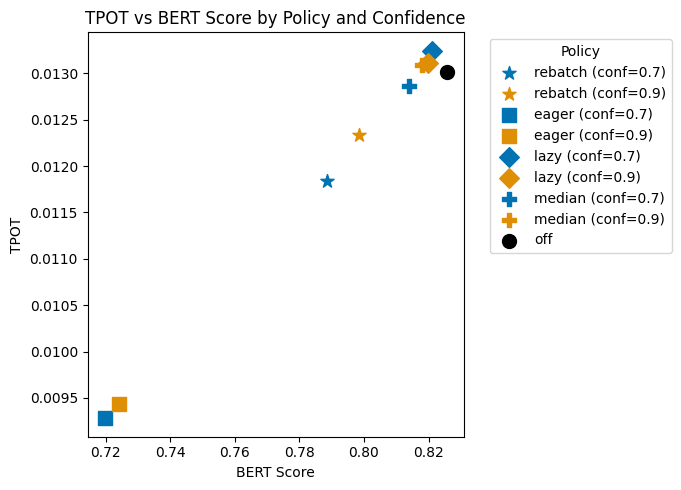

In [4]:
def plot_tpot_vs_bert_from_csvs(data_dir):
    # Define policies and markers
    policies = {
        "rebatching": {"label": "rebatch", "marker": "*"},
        "eager": {"label": "eager", "marker": "s"},
        "lazy": {"label": "lazy", "marker": "D"},
        "median": {"label": "median", "marker": "P"},
        "off": {"label": "off", "marker": "o", "color": "black"},
    }
    confs = ["0.7", "0.9"]
    layers = ["50"]


    # Prepare data
    rows = []

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # Extract policy and conf from filename
        # Pattern: req_100_batch_4_layer_<layer>_conf_<conf>_<policy>_copy.csv
        m = re.search(r"layer_([0-9]+)_conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
        if m:
            layer = m.group(1)
            conf = m.group(2)
            policy = m.group(3)
            
            if policy not in policies:
                continue

            if layer not in layers:
                continue
            if conf not in confs:
                continue

            df = pd.read_csv(csv_path)
            tpot = df["tpot"].mean()
            bert_score = df["bert_score"].mean()
            rows.append({
                "policy": policy,
                "layer": layer,
                "conf": conf,
                "tpot": tpot,
                "bert_score": bert_score,
            })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points:")
    print(plot_df)

    # Set up color palette for confs
    palette = sns.color_palette("colorblind", n_colors=2)
    conf_color_map = {c: palette[i] for i, c in enumerate(confs)}

    fig, ax = plt.subplots(figsize=(7, 5))

    # Plot each policy
    for policy, info in policies.items():
        if policy == "off":
            # Only one point, no conf
            subdf = plot_df[plot_df["policy"] == "off"]
            if not subdf.empty:
                ax.scatter(
                    subdf["bert_score"], subdf["tpot"],
                    marker=info["marker"], color=info["color"], s=100, label="off"
                )
        else:
            for conf in confs:
                subdf = plot_df[(plot_df["policy"] == policy) & (plot_df["conf"] == conf)]
                if not subdf.empty:
                    ax.scatter(
                        subdf["bert_score"], subdf["tpot"],
                        marker=info["marker"], color=conf_color_map[conf], s=100,
                        label=f"{info['label']} (conf={conf})"
                    )

    # Remove duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    new_handles, new_labels = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            new_handles.append(h)
            new_labels.append(l)
            seen.add(l)
    ax.legend(new_handles, new_labels, title="Policy", bbox_to_anchor=(1.05, 1), loc='upper left')

    ax.set_xlabel("BERT Score")
    ax.set_ylabel("TPOT")
    ax.set_title("TPOT vs BERT Score by Policy and Confidence")
    plt.tight_layout()
    plt.show()


plot_tpot_vs_bert_from_csvs(data_dir)

Found 'Off' policy baseline throughput: 72.20
Found 8 data points for main policies:
       policy conf  ee_proportion  throughput
0  rebatching  0.7      33.127426   78.917561
1      median  0.7       6.386352   73.313402
2       eager  0.7      97.952650  101.367077
3        lazy  0.7       1.166530   70.939380
4  rebatching  0.9      18.048149   76.141871
5      median  0.9       1.894596   72.046054
6        lazy  0.9       0.203848   71.542930
7       eager  0.9      92.328021   99.886341


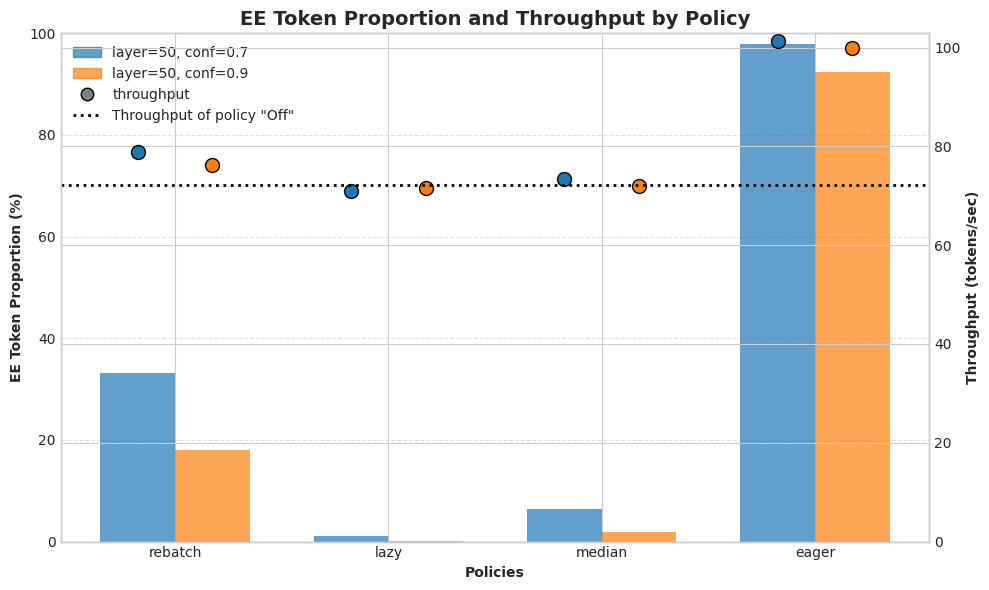

In [36]:
def plot_ee_proportion_and_throughput(data_dir):
    """
    Plots EE token proportion and throughput, including a baseline "Off" policy.

    This function creates a bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Left Y-axis: EE Token Proportion (%)
    - Right Y-axis: Throughput (overlaid as dots)
    - A horizontal dotted line shows the throughput of the "Off" policy.
    """
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    # 1. Read baseline "Off" policy data from "off.csv"
    off_throughput = None
    off_csv_path = data_dir / "req_100_batch_4_layer_50_conf_0.7_off_copy.csv"
    if off_csv_path.exists():
        df_off = pd.read_csv(off_csv_path)
        if "throughput" in df_off.columns:
            off_throughput = df_off["throughput"].mean()
            print(f"Found 'Off' policy baseline throughput: {off_throughput:.2f}")
    else:
        print("Note: 'req_100_batch_4_layer_50_conf_0.7_off_copy.csv' not found. Skipping baseline throughput line.")

    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager"
    }
    confs = ["0.7", "0.9"]

    # Prepare data for other policies
    rows = []
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
        if m:
            conf, policy = m.group(1), m.group(2)
            if policy in policies and conf in confs:
                df = pd.read_csv(csv_path)
                total_tokens = df["num_ee_tokens"].mean() + df["num_no_ee_tokens"].mean()
                ee_prop = (df["num_ee_tokens"].mean() / total_tokens) * 100 if total_tokens > 0 else 0
                rows.append({
                    "policy": policy,
                    "conf": conf,
                    "ee_proportion": ee_prop,
                    "throughput": df["throughput"].mean(),
                })

    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points for main policies:\n{plot_df}")

    # Set up the plot
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    policy_names = list(policies.values())
    x_positions = np.arange(len(policy_names))
    bar_width = 0.35
    colors = ['#1f77b4', '#ff7f0e']

    # --- Plotting Bars and Dots ---
    for i, conf in enumerate(confs):
        x_offset = i * bar_width - bar_width / 2
        for j, policy in enumerate(policies.keys()):
            data = plot_df[(plot_df["policy"] == policy) & (plot_df["conf"] == conf)]
            if not data.empty:
                d = data.iloc[0]
                ax1.bar(j + x_offset, d["ee_proportion"], bar_width, color=colors[i], alpha=0.7)
                ax2.scatter(j + x_offset, d["throughput"], color=colors[i], s=100, marker='o', edgecolors='black', linewidth=1)

    # 2. Plot the baseline "Off" policy throughput if available
    if off_throughput is not None:
        ax2.axhline(y=off_throughput, color='black', linestyle=':', linewidth=2)

    # --- Legend Creation ---
    legend_handles = [
        mpatches.Patch(color=colors[0], label='layer=50, conf=0.7', alpha=0.7),
        mpatches.Patch(color=colors[1], label='layer=50, conf=0.9', alpha=0.7),
        mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=9,
                      markeredgecolor='black', label='throughput')
    ]

    # 3. Add handle for the "Off" policy line to the legend
    if off_throughput is not None:
        off_handle = mlines.Line2D([], [], color='black', linestyle=':',
                                   linewidth=2, label='Throughput of policy "Off"')
        legend_handles.append(off_handle)

    ax1.legend(handles=legend_handles, loc='upper left')

    # --- Plot Customization ---
    ax1.set_xlabel('Policies', fontweight='bold')
    ax1.set_ylabel('EE Token Proportion (%)', fontweight='bold')
    ax2.set_ylabel('Throughput (tokens/sec)', fontweight='bold')
    ax1.set_title('EE Token Proportion and Throughput by Policy', fontweight='bold', fontsize=14)
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(policy_names)
    ax1.set_ylim(0, 100)
    ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

    if not plot_df.empty and plot_df['throughput'].min() > 0:
        ax2.set_ylim(bottom=0)

    fig.tight_layout()
    plt.show()

plot_ee_proportion_and_throughput(data_dir)

Found 8 data points:
       policy conf  ee_penalty
0       eager  0.7    0.045771
1  rebatching  0.9    0.099336
2       eager  0.9    0.046578
3      median  0.7    0.163551
4      median  0.9    0.448831
5        lazy  0.7    0.641519
6        lazy  0.9    4.177399
7  rebatching  0.7    0.073704


/tmp/ipykernel_56038/2671595641.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(policies.values())


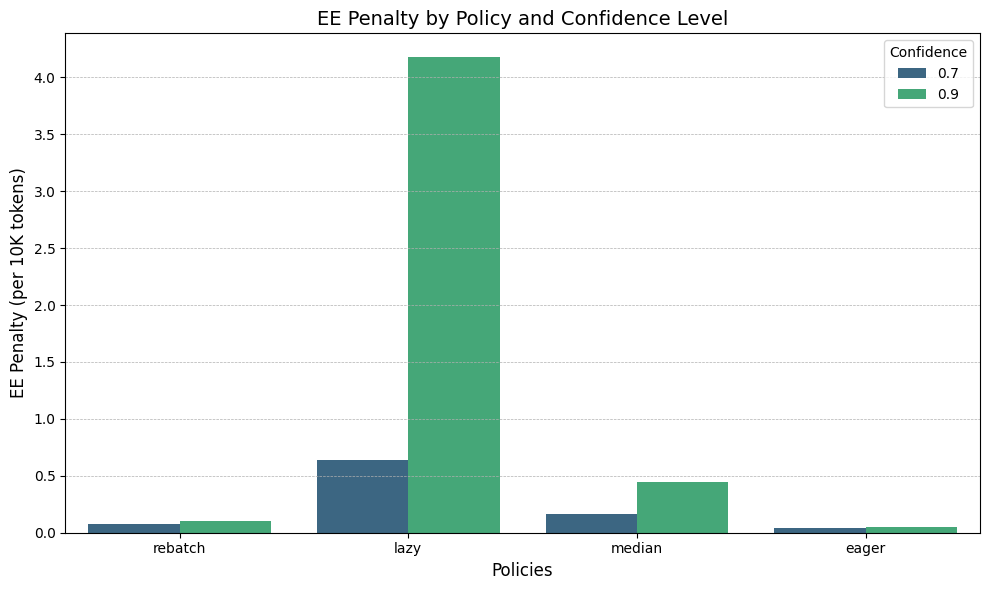

In [6]:
def plot_ee_penalty(data_dir):
    """
    Plot EE token proportion and throughput by policy and confidence level.
    
    This function creates a grouped bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Y-axis: ee penalty
    - Each policy has 2 separated bars: conf=0.8 and conf=0.9
    """
    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy", 
        "median": "median",
        "eager": "eager"
    }

    # Define confidence levels
    confs = ["0.7", "0.9"]
    
    # Prepare data
    rows = []
    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # Extract policy and conf from filename
        m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
        if m:
            conf = m.group(1)
            policy_key = m.group(2)
            
            if policy_key not in policies or conf not in confs:
                continue

            df = pd.read_csv(csv_path)
            avg_ee_penalty = df["ee_bert_penalty_by_tokens"].mean() * 10000
            
            rows.append({
                "policy": policy_key,
                "conf": conf,
                "ee_penalty": avg_ee_penalty,
            })

    if not rows:
        print("No data found to plot. Check your data_dir and file naming pattern.")
        return
        
    plot_df = pd.DataFrame(rows)
    print(f"Found {len(plot_df)} data points:")
    print(plot_df)

    # --- Plotting ---
    plt.figure(figsize=(10, 6))
    
    # Use seaborn's `hue` parameter to automatically create grouped bars
    ax = sns.barplot(
        data=plot_df,
        x='policy',
        y='ee_penalty',
        hue='conf',
        order=list(policies.keys()), # Ensure policies are in the correct order
        palette='viridis' # A visually distinct color palette
    )

    # Customize the plot
    ax.set_xlabel('Policies', fontsize=12)
    ax.set_ylabel('EE Penalty (per 10K tokens)', fontsize=12)
    ax.set_title('EE Penalty by Policy and Confidence Level', fontsize=14)
    
    # Set the x-axis labels to the desired display names
    ax.set_xticklabels(policies.values())
    
    # Set y-axis limits and add grid
    # plt.ylim(0, 100)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')
    
    # Customize legend
    plt.legend(title='Confidence')
    
    plt.tight_layout()
    plt.show()


plot_ee_penalty(data_dir)

Found the following data points:
       policy conf  throughput  bert_score
0       eager  0.7  101.367077    0.719645
1         off  N/A   72.195163    0.825638
2  rebatching  0.9   76.141871    0.798451
3       eager  0.9   99.886341    0.724054
4      median  0.7   73.313402    0.813976
5      median  0.9   72.046054    0.817864
6        lazy  0.7   70.939380    0.821211
7        lazy  0.9   71.542930    0.819711
8  rebatching  0.7   78.917561    0.788414

Baseline 'Off' throughput: 72.20, BERT score: 0.8256


/tmp/ipykernel_56038/2396279617.py:90: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(policies.values())


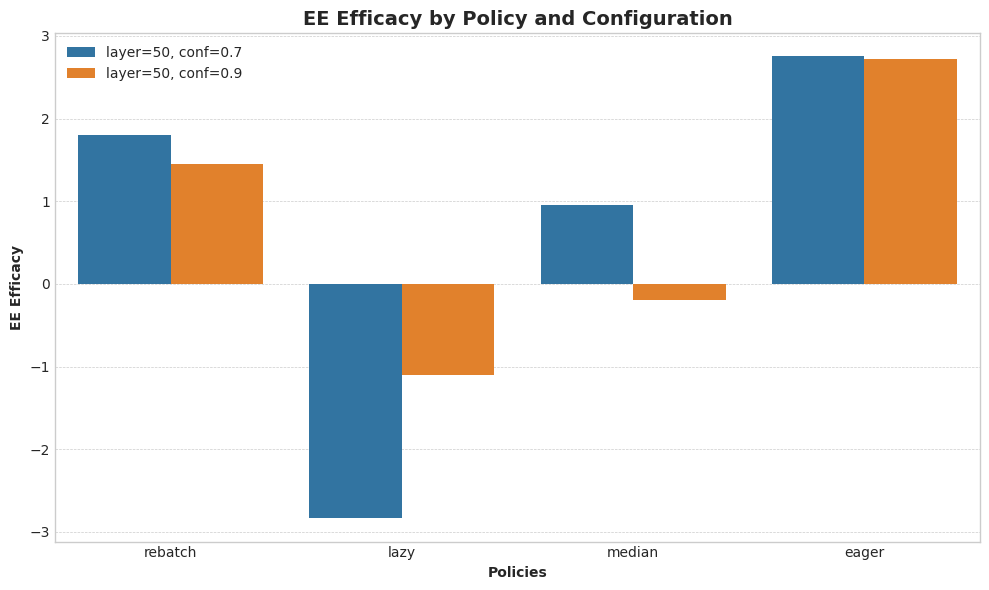

In [7]:
def plot_ee_efficacy(data_dir: Path):
    """
    Plots EE efficacy by policy and configuration.

    This function creates a grouped bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Y-axis: EE efficacy, calculated relative to a baseline 'off' policy.
    - Each policy has two grouped bars representing different configurations.
    """
    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager"
    }

    # Prepare data
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # The 'off' policy is used as a baseline and has a different filename format
        if fname == "req_100_batch_4_layer_50_conf_0.7_off_copy.csv":
            policy_key = "off"
            conf = "N/A" # Confidence is not applicable to the 'off' policy
        else:
            m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
            if not m:
                continue
            conf, policy_key = m.group(1), m.group(2)

        # Skip files that don't match our policies of interest
        if policy_key not in policies and policy_key != "off":
            continue

        df = pd.read_csv(csv_path)
        rows.append({
            "policy": policy_key,
            "conf": conf,
            "throughput": df["throughput"].mean(),
            "bert_score": df["bert_score"].mean(),
        })

    if not rows:
        print("No data found. Check your data directory and file naming.")
        return

    plot_df = pd.DataFrame(rows)
    print("Found the following data points:")
    print(plot_df)

    # Extract baseline values from the 'off' policy
    try:
        off_policy_data = plot_df[plot_df["policy"] == "off"].iloc[0]
        off_throughput = off_policy_data["throughput"]
        off_bert_score = off_policy_data["bert_score"]
        print(f"\nBaseline 'Off' throughput: {off_throughput:.2f}, BERT score: {off_bert_score:.4f}")
    except IndexError:
        print("Error: Baseline 'off.csv' data not found. Cannot calculate efficacy.")
        return

    # Filter out the 'off' policy before calculating efficacy for the other policies
    plot_df = plot_df[plot_df["policy"] != "off"].copy()
    # Efficacy: Throughput gain per 0.01 drop in BERT score
    plot_df["ee_efficacy"] = (plot_df["throughput"] - off_throughput) / ((off_bert_score - plot_df["bert_score"]) * 100)

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))

    # 1. Use the specified colorblind-friendly palette
    colors = ['#1f77b4', '#ff7f0e']

    ax = sns.barplot(
        data=plot_df,
        x='policy',
        y='ee_efficacy',
        hue='conf',
        order=list(policies.keys()),
        palette=colors
    )

    # Customize the plot
    ax.set_xlabel('Policies', fontweight='bold')
    ax.set_ylabel('EE Efficacy', fontweight='bold')
    ax.set_title('EE Efficacy by Policy and Configuration', fontweight='bold', fontsize=14)
    ax.set_xticklabels(policies.values())
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')

    # 2. Customize legend with specified labels
    handles, _ = ax.get_legend_handles_labels()
    new_labels = ['layer=50, conf=0.7', 'layer=50, conf=0.9']
    ax.legend(handles, new_labels)

    plt.tight_layout()
    plt.show()

plot_ee_efficacy(data_dir)

Found the following data points:
       policy conf  throughput  avg_conf_score_ee
0         off  N/A   72.195163           0.000000
1  rebatching  0.7   78.917561           0.940785
2      median  0.7   73.313402           0.754588
3       eager  0.7  101.367077           0.789000
4        lazy  0.7   70.939380           0.907102
5  rebatching  0.9   76.141871           0.979439
6      median  0.9   72.046054           0.826322
7        lazy  0.9   71.542930           0.967640
8       eager  0.9   99.886341           0.782446


/tmp/ipykernel_11283/4293052457.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(policies.values())


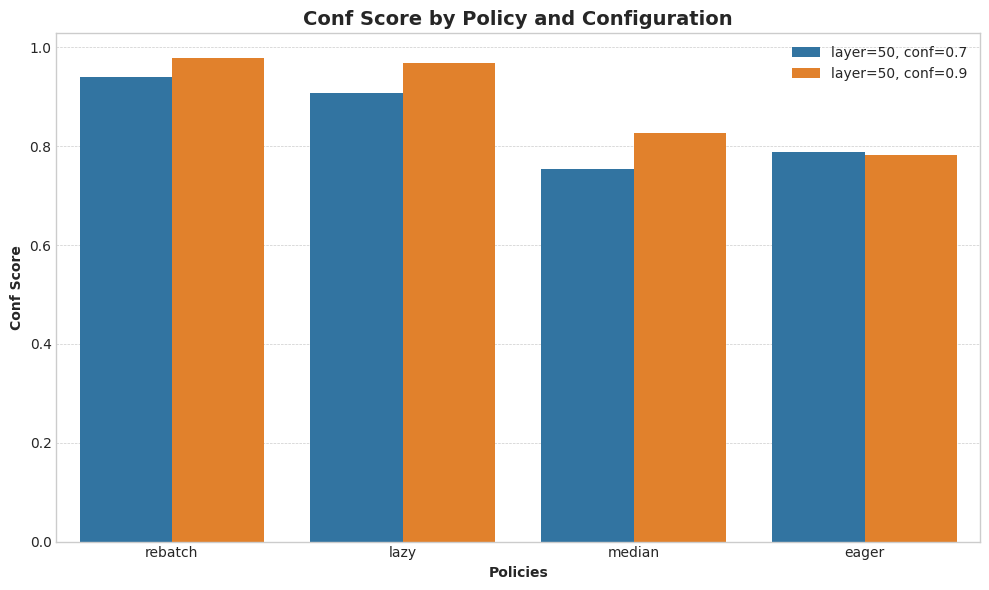

In [18]:
def plot_conf_score(data_dir: Path):
    """
    Plots EE efficacy by policy and configuration.

    This function creates a grouped bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Y-axis: EE efficacy, calculated relative to a baseline 'off' policy.
    - Each policy has two grouped bars representing different configurations.
    """
    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager"
    }

    # Prepare data
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # The 'off' policy is used as a baseline and has a different filename format
        if fname == "req_100_batch_4_layer_50_conf_0.7_off_copy.csv":
            policy_key = "off"
            conf = "N/A" # Confidence is not applicable to the 'off' policy
        else:
            m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
            if not m:
                continue
            conf, policy_key = m.group(1), m.group(2)

        # Skip files that don't match our policies of interest
        if policy_key not in policies and policy_key != "off":
            continue

        df = pd.read_csv(csv_path)
        rows.append({
            "policy": policy_key,
            "conf": conf,
            "throughput": df["throughput"].mean(),
            "avg_conf_score_ee": df["avg_conf_score_ee"].mean(),
        })

    if not rows:
        print("No data found. Check your data directory and file naming.")
        return

    plot_df = pd.DataFrame(rows)
    print("Found the following data points:")
    print(plot_df)


    # Filter out the 'off' policy before calculating efficacy for the other policies
    plot_df = plot_df[plot_df["policy"] != "off"].copy()


    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))

    # 1. Use the specified colorblind-friendly palette
    colors = ['#1f77b4', '#ff7f0e']

    ax = sns.barplot(
        data=plot_df,
        x='policy',
        y='avg_conf_score_ee',
        hue='conf',
        order=list(policies.keys()),
        palette=colors
    )

    # Customize the plot
    ax.set_xlabel('Policies', fontweight='bold')
    ax.set_ylabel('Conf Score', fontweight='bold')
    ax.set_title('Conf Score by Policy and Configuration', fontweight='bold', fontsize=14)
    ax.set_xticklabels(policies.values())
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')

    # 2. Customize legend with specified labels
    handles, _ = ax.get_legend_handles_labels()
    new_labels = ['layer=50, conf=0.7', 'layer=50, conf=0.9']
    ax.legend(handles, new_labels)

    plt.tight_layout()
    plt.show()

plot_conf_score(data_dir)

Found the following data points:
       policy conf  throughput   TBT_p99
0         off  N/A   72.195163  0.054257
1  rebatching  0.7   78.917561  0.053030
2      median  0.7   73.313402  0.052977
3       eager  0.7  101.367077  0.052157
4        lazy  0.7   70.939380  0.053420
5  rebatching  0.9   76.141871  0.053626
6      median  0.9   72.046054  0.053994
7        lazy  0.9   71.542930  0.053596
8       eager  0.9   99.886341  0.052038


/tmp/ipykernel_11283/3047174696.py:68: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(
/tmp/ipykernel_11283/3047174696.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(policies.values())


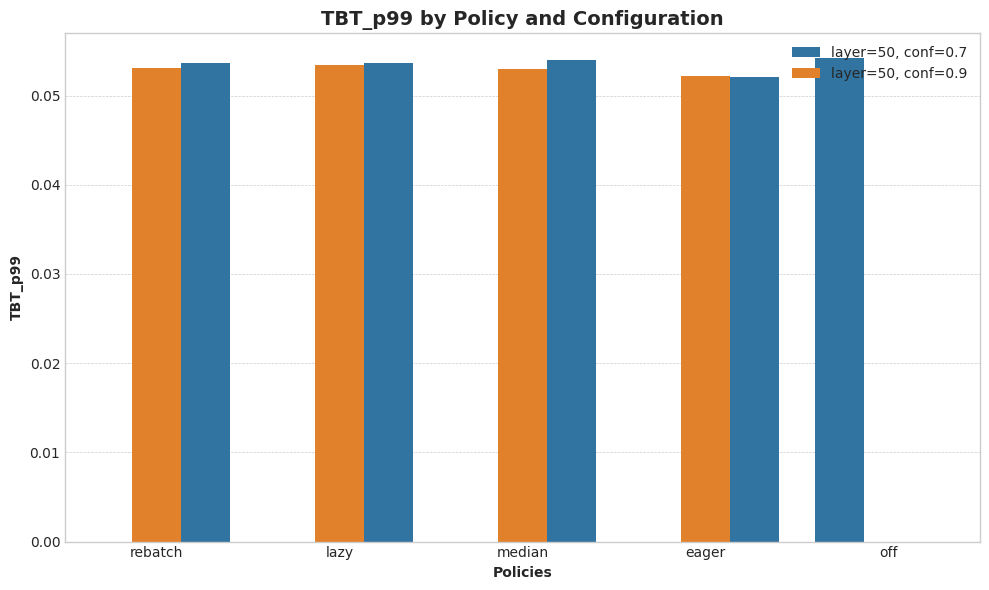

In [24]:
def plot_TBT_p99(data_dir: Path):
    """
    Plots EE efficacy by policy and configuration.

    This function creates a grouped bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Y-axis: EE efficacy, calculated relative to a baseline 'off' policy.
    - Each policy has two grouped bars representing different configurations.
    """
    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager",
        "off": "off"
    }

    # Prepare data
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # The 'off' policy is used as a baseline and has a different filename format
        if fname == "req_100_batch_4_layer_50_conf_0.7_off_copy.csv":
            policy_key = "off"
            conf = "N/A" # Confidence is not applicable to the 'off' policy
        else:
            m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
            if not m:
                continue
            conf, policy_key = m.group(1), m.group(2)

        # Skip files that don't match our policies of interest
        if policy_key not in policies and policy_key != "off":
            continue

        df = pd.read_csv(csv_path)
        rows.append({
            "policy": policy_key,
            "conf": conf,
            "throughput": df["throughput"].mean(),
            "TBT_p99": df["tbt_p99"].mean(),
        })

    if not rows:
        print("No data found. Check your data directory and file naming.")
        return

    plot_df = pd.DataFrame(rows)
    print("Found the following data points:")
    print(plot_df)


    # Filter out the 'off' policy before calculating efficacy for the other policies
    #plot_df = plot_df[plot_df["policy"] != "off"].copy()


    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))

    # 1. Use the specified colorblind-friendly palette
    colors = ['#1f77b4', '#ff7f0e']

    ax = sns.barplot(
        data=plot_df,
        x='policy',
        y='TBT_p99',
        hue='conf',
        order=list(policies.keys()),
        palette=colors
    )

    # Customize the plot
    ax.set_xlabel('Policies', fontweight='bold')
    ax.set_ylabel('TBT_p99', fontweight='bold')
    ax.set_title('TBT_p99 by Policy and Configuration', fontweight='bold', fontsize=14)
    ax.set_xticklabels(policies.values())
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')

    # 2. Customize legend with specified labels
    handles, _ = ax.get_legend_handles_labels()
    new_labels = ['layer=50, conf=0.7', 'layer=50, conf=0.9']
    ax.legend(handles, new_labels)

    plt.tight_layout()
    plt.show()

plot_TBT_p99(data_dir)

Found the following data points:
       policy conf  throughput   TBT_avg
0         off  N/A   72.195163  0.052003
1  rebatching  0.7   78.917561  0.036097
2      median  0.7   73.313402  0.051064
3       eager  0.7  101.367077  0.037473
4        lazy  0.7   70.939380  0.052290
5  rebatching  0.9   76.141871  0.039204
6      median  0.9   72.046054  0.051359
7        lazy  0.9   71.542930  0.051779
8       eager  0.9   99.886341  0.038146


/tmp/ipykernel_11283/3236955398.py:68: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(
/tmp/ipykernel_11283/3236955398.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(policies.values())


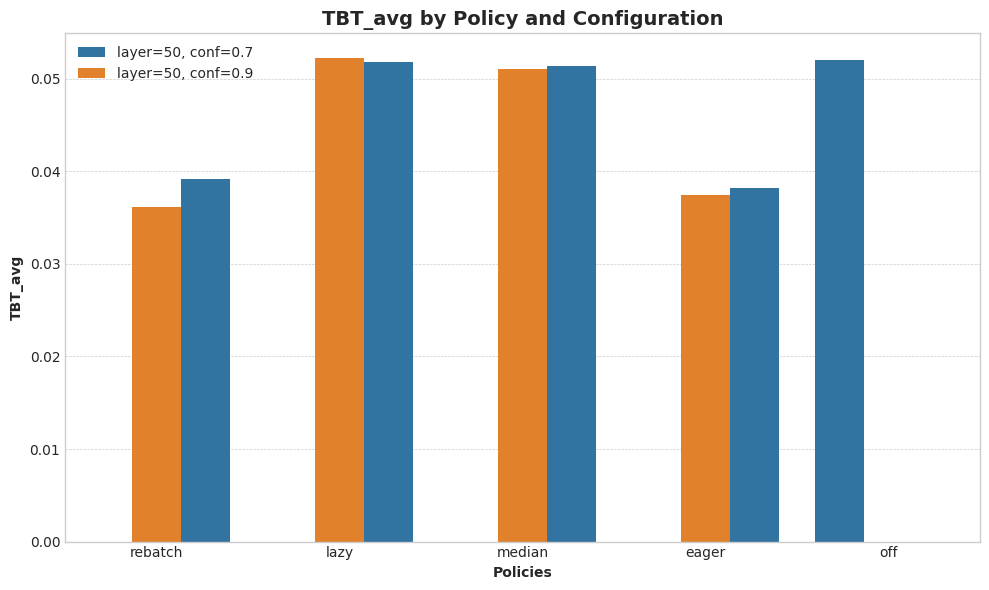

In [25]:
def plot_TBT_avg(data_dir: Path):
    """
    Plots EE efficacy by policy and configuration.

    This function creates a grouped bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Y-axis: EE efficacy, calculated relative to a baseline 'off' policy.
    - Each policy has two grouped bars representing different configurations.
    """
    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager",
        "off": "off"
    }

    # Prepare data
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # The 'off' policy is used as a baseline and has a different filename format
        if fname == "req_100_batch_4_layer_50_conf_0.7_off_copy.csv":
            policy_key = "off"
            conf = "N/A" # Confidence is not applicable to the 'off' policy
        else:
            m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
            if not m:
                continue
            conf, policy_key = m.group(1), m.group(2)

        # Skip files that don't match our policies of interest
        if policy_key not in policies and policy_key != "off":
            continue

        df = pd.read_csv(csv_path)
        rows.append({
            "policy": policy_key,
            "conf": conf,
            "throughput": df["throughput"].mean(),
            "TBT_avg": df["tbt_avg"].mean(),
        })

    if not rows:
        print("No data found. Check your data directory and file naming.")
        return

    plot_df = pd.DataFrame(rows)
    print("Found the following data points:")
    print(plot_df)


    # Filter out the 'off' policy before calculating efficacy for the other policies
    #plot_df = plot_df[plot_df["policy"] != "off"].copy()


    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))

    # 1. Use the specified colorblind-friendly palette
    colors = ['#1f77b4', '#ff7f0e']

    ax = sns.barplot(
        data=plot_df,
        x='policy',
        y='TBT_avg',
        hue='conf',
        order=list(policies.keys()),
        palette=colors
    )

    # Customize the plot
    ax.set_xlabel('Policies', fontweight='bold')
    ax.set_ylabel('TBT_avg', fontweight='bold')
    ax.set_title('TBT_avg by Policy and Configuration', fontweight='bold', fontsize=14)
    ax.set_xticklabels(policies.values())
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')

    # 2. Customize legend with specified labels
    handles, _ = ax.get_legend_handles_labels()
    new_labels = ['layer=50, conf=0.7', 'layer=50, conf=0.9']
    ax.legend(handles, new_labels)

    plt.tight_layout()
    plt.show()

plot_TBT_avg(data_dir)

Found the following data points:
       policy conf  request_duration_avg_normalized_by_tokens
0         off  N/A                                   0.000538
1  rebatching  0.7                                   0.000831
2      median  0.7                                   0.000528
3       eager  0.7                                   0.000381
4        lazy  0.7                                   0.000543
5  rebatching  0.9                                   0.000833
6      median  0.9                                   0.000532
7        lazy  0.9                                   0.000537
8       eager  0.9                                   0.000387


/tmp/ipykernel_11283/3992158750.py:67: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(
/tmp/ipykernel_11283/3992158750.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(policies.values())


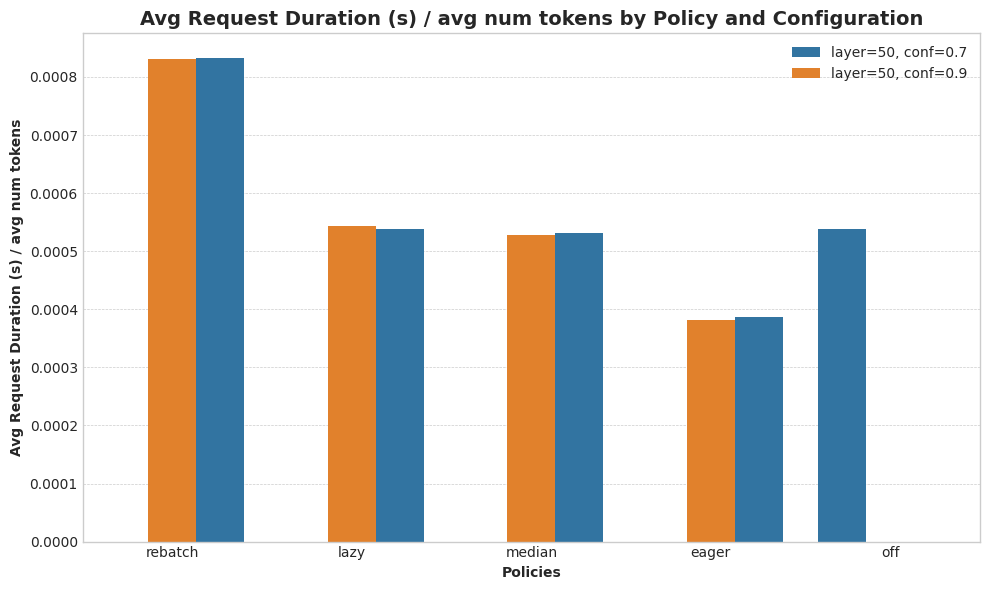

In [33]:
def plot_request_duration_avg_over_tokens(data_dir: Path):
    """
    Plots EE efficacy by policy and configuration.

    This function creates a grouped bar chart showing:
    - X-axis: Policies (rebatch, lazy, median, eager)
    - Y-axis: EE efficacy, calculated relative to a baseline 'off' policy.
    - Each policy has two grouped bars representing different configurations.
    """
    # Define policies and their display names
    policies = {
        "rebatching": "rebatch",
        "lazy": "lazy",
        "median": "median",
        "eager": "eager",
        "off": "off"
    }

    # Prepare data
    rows = []
    if not isinstance(data_dir, Path):
        data_dir = Path(data_dir)

    for csv_path in data_dir.glob("*.csv"):
        fname = csv_path.name
        # The 'off' policy is used as a baseline and has a different filename format
        if fname == "req_100_batch_4_layer_50_conf_0.7_off_copy.csv":
            policy_key = "off"
            conf = "N/A" # Confidence is not applicable to the 'off' policy
        else:
            m = re.search(r"conf_([0-9.]+)_([a-z]+)_copy\.csv$", fname)
            if not m:
                continue
            conf, policy_key = m.group(1), m.group(2)

        # Skip files that don't match our policies of interest
        if policy_key not in policies and policy_key != "off":
            continue

        df = pd.read_csv(csv_path)
        rows.append({
            "policy": policy_key,
            "conf": conf,
            "request_duration_avg_normalized_by_tokens": df["request_duration_avg"].mean() / (df["throughput"].mean() * df["time"].mean()),
        })

    if not rows:
        print("No data found. Check your data directory and file naming.")
        return

    plot_df = pd.DataFrame(rows)
    print("Found the following data points:")
    print(plot_df)


    # Filter out the 'off' policy before calculating efficacy for the other policies
    #plot_df = plot_df[plot_df["policy"] != "off"].copy()


    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(10, 6))

    # 1. Use the specified colorblind-friendly palette
    colors = ['#1f77b4', '#ff7f0e']

    ax = sns.barplot(
        data=plot_df,
        x='policy',
        y='request_duration_avg_normalized_by_tokens',
        hue='conf',
        order=list(policies.keys()),
        palette=colors
    )

    # Customize the plot
    ax.set_xlabel('Policies', fontweight='bold')
    ax.set_ylabel('Avg Request Duration (s) / avg num tokens', fontweight='bold')
    ax.set_title('Avg Request Duration (s) / avg num tokens by Policy and Configuration', fontweight='bold', fontsize=14)
    ax.set_xticklabels(policies.values())
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')

    # 2. Customize legend with specified labels
    handles, _ = ax.get_legend_handles_labels()
    new_labels = ['layer=50, conf=0.7', 'layer=50, conf=0.9']
    ax.legend(handles, new_labels)

    plt.tight_layout()
    plt.show()

plot_request_duration_avg_over_tokens(data_dir)